# Multi-Output GP

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from datasets import load_dataset
from data_processing import (
    process_one_obj_one_band, 
    process_one_obj_one_band_train_heldout, 
    split_train_heldout_observations, 
    select_examples_and_process_train_heldout, 
    _select_usable_examples,
)
from MOGP_model import (
    run_mogp_evaluation,
    process_one_obj_mogp_train_heldout,
    fit_mogp_gp,
    run_target_band_ablation_study,
)
from evaluation_metrics import (
    evaluate_mogp_heldout_metrics,
    summarize_metrics_by_band,
    aggregate_gp_ablation_results,
    compare_models_aggregated,
    save_gp_ablation_reports,
    evaluate_heldout_metrics,
)
from singleGP_model import (
    fit_basic_gp,
)
from visualization import (
    plot_gp_fit,
    plot_multiband_gp_single_band_prediction,
    plot_largest_standardized_residual_cases,
)


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")

In [6]:
mogp_params = {
    "heldout_fraction": 0.2,
    "min_train_points": 5,
    "scale_mode": "local_peak",
    "time_length_scale": 0.3,
    "wavelength_length_scale": 200.0,
    "n_restarts_optimizer": 0,
}

result = run_mogp_evaluation(
    dset_plasticc,
    n_objects=10,
    **mogp_params,
)

total train: 76
total heldout: 22
MOGP learned kernel: 0.373**2 * Matern(length_scale=[0.33, 20], nu=1.5)
total train: 73
total heldout: 22
MOGP learned kernel: 0.438**2 * Matern(length_scale=[2.25, 2e+03], nu=1.5)
total train: 79
total heldout: 22
MOGP learned kernel: 0.323**2 * Matern(length_scale=[0.487, 498], nu=1.5)
total train: 79
total heldout: 22
total train: 79
total heldout: 23
total train: 81
total heldout: 22


/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 20.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 2000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(

total train: 78
total heldout: 22
total train: 76
total heldout: 21
total train: 74
total heldout: 22
total train: 81
total heldout: 23


In [4]:
import pandas as pd
import numpy as np

rows = []
for m in result["object_results"]:
    z = (m["y_true_raw"] - m["y_pred_raw"]) / np.maximum(m["y_std_raw"], 1e-12)

    for i in range(m["n_heldout"]):
        rows.append({
            "object_id": m["object_id"][i],
            "band": m["band"][i],
            "time": m["time"][i],
            "y_true": m["y_true_raw"][i],
            "y_pred": m["y_pred_raw"][i],
            "y_std": m["y_std_raw"][i],
            "z": z[i],
            "abs_z": abs(z[i]),
        })

df = pd.DataFrame(rows)
df.sort_values("abs_z", ascending=False).head(20)

,object_id,band,time,y_true,y_pred,y_std,z,abs_z
14,21846282,r,0.065589,40.877480,72.772604,8.204328,-3.887597,3.887597
43,114421739,i,2.656343,-18.363379,1.050943,6.906805,-2.810898,2.810898
142,16775731,z,-0.049775,-22.325037,39.631278,22.248975,-2.784682,2.784682
8,21846282,r,-0.299802,0.951507,18.877242,7.578400,-2.365372,2.365372
33,114421739,r,1.512123,2.520881,14.638953,5.156114,-2.350234,2.350234
144,16775731,u,0.023137,14.030240,50.351505,16.155480,-2.248232,2.248232
11,21846282,z,-0.166034,-8.066343,19.159370,12.589182,-2.162628,2.162628
167,31971611,z,0.164612,-0.418611,30.364599,15.687420,-1.962286,1.962286
38,114421739,z,2.448782,-20.877531,4.411828,13.299893,-1.901471,1.901471
196,50875482,i,2.729796,7.258542,-1.193511,4.569158,1.849805,1.849805


In [5]:
print(result["aggregate"]["observation_weighted"])
print(result["aggregate"]["object_weighted"])

{'nlpd': 3.924748409314256, 'rmse': 25.385498257359902, 'coverage_1sigma': 0.751131221719457, 'coverage_2sigma': 0.9683257918552036, 'coverage_3sigma': 0.995475113122172}
{'nlpd': 3.9217871861116853, 'rmse': 18.216961200555744, 'coverage_1sigma': 0.7522962544701675, 'coverage_2sigma': 0.9681818181818181, 'coverage_3sigma': 0.9954545454545455}


# Use the same amount of data points for comparison

In [16]:
dataloader = iter(dset_plasticc)

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 2000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


MOGP learned kernel: 0.542**2 * Matern(length_scale=[0.0747, 2e+03], nu=1.5)
{'n_heldout': 20, 'nlpd': 4.724942662511064, 'rmse': 31.438218202650166, 'coverage_1sigma': 0.65, 'coverage_2sigma': 0.95, 'coverage_3sigma': 1.0}


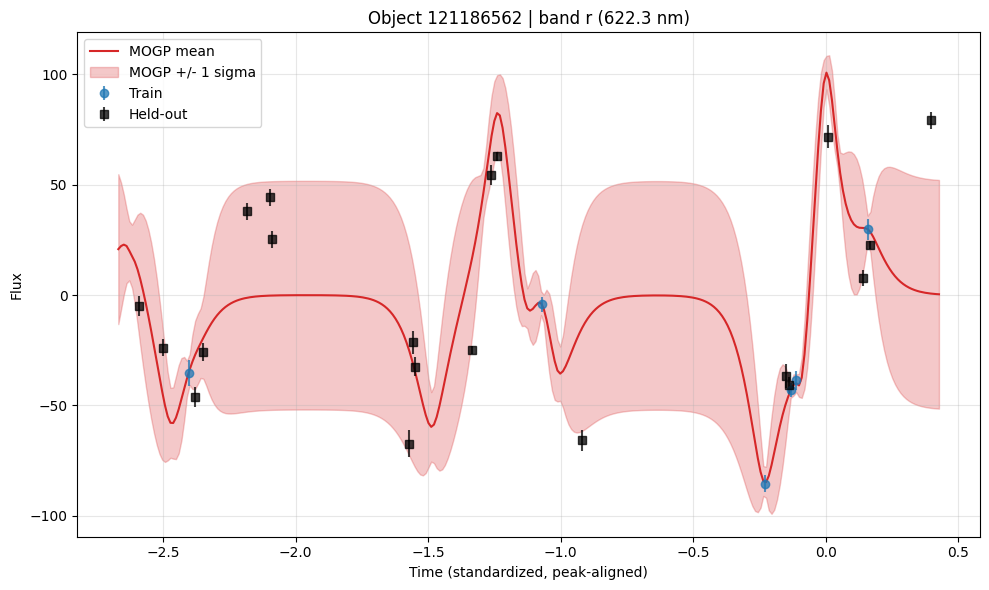

In [21]:
example = next(dataloader)

train_data, heldout_data = process_one_obj_mogp_train_heldout(example, background_mode="band", scale_mode="local_peak", subsample_reference_band='r')
gp_multi = fit_mogp_gp(train_data)
metrics = evaluate_mogp_heldout_metrics(
            gp_multi,
            heldout_data,
            train_data=train_data,
        )
summary = summarize_metrics_by_band([metrics])
print(summary["r"])

fig, ax = plot_multiband_gp_single_band_prediction(
        gp_multi,
        object_data=train_data["obj_id"],
        selected_band="r",
        train_data=train_data,
        heldout_data=heldout_data,
    )


Compare the evaluation metric averaged across all bands

Compare with single band GP:

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


MOGP learned kernel: 0.616**2 * Matern(length_scale=0.05, nu=1.5)
NLPD: 4.757361478677957
RMSE: 24.020296449146116
Coverage:
k=1 1.0
k=2 1.0
k=3 1.0


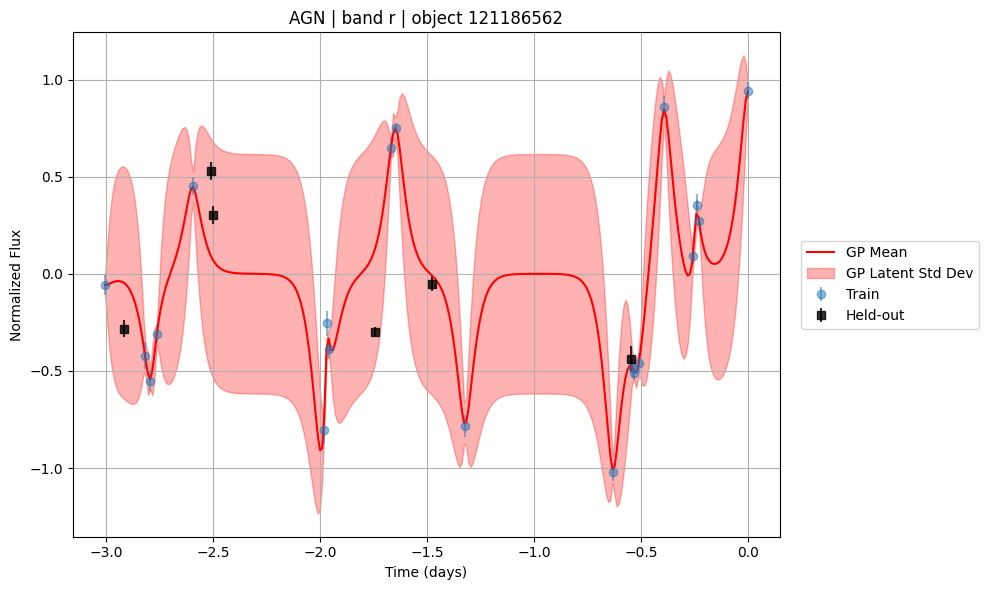

In [24]:
data = process_one_obj_one_band(example, target_band='r')
train_data_s, heldout_data_s = split_train_heldout_observations(
    data,
    heldout_fraction=0.2,
    random_state=0,
    strategy="random",  # or "last"
)

gp = fit_basic_gp(train_data_s, kernel_type="matern")
summary = evaluate_heldout_metrics(gp, heldout_data_s, train_data=train_data_s)


print("NLPD:", summary["mean_nlpd"])
print("RMSE:", summary["rmse"])
print("Coverage:")
print("k=1", summary["coverage"]["coverage_1sigma"])
print("k=2", summary["coverage"]["coverage_2sigma"])
print("k=3", summary["coverage"]["coverage_3sigma"])
plot_gp_fit(gp, train_data_s, heldout_data=heldout_data_s)

Under a fixed total training budget, the MOGP has fewer target-band observations than the single-band GP, so worse RMSE is not surprising. The fact that its NLPD is slightly better and its coverage is closer to nominal suggests that the multi-band model may provide more realistic uncertainty, but this should be checked over many objects. 

Evaluate and compare the metrics over 100 objects. 
1. The multi-band GP 
2. The single-band GP

# Comparing 6 Models

In [5]:
dataloader = iter(dset_plasticc)
example = next(dataloader)
result = run_target_band_ablation_study(
    example,
    target_band="r",
    bands=("u", "g", "r", "i", "z"),
    aux_band_ratios={
        "u": 0.0,
        "g": 0.5,
        "i": 1.0,
        "z": 0.0,
    },
    shuffle_repeats=5,
    random_state=0,
    mogp_gp_kwargs={
        "n_restarts_optimizer": 0,
        "print_kernel": False,
    },
)

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 2000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

In [28]:
df = pd.DataFrame(result["rows"])
df[
    [
        "model",
        "object_id",
        "target_band",
        "n_train_target_band",
        "n_train_other_bands",
        "n_heldout_target_band",
        "rmse",
        "nlpd",
        "coverage_1sigma",
        "coverage_2sigma",
        "coverage_3sigma",
        "z_score_mean",
        "z_score_std",
    ]
]

,model,object_id,target_band,n_train_target_band,n_train_other_bands,n_heldout_target_band,rmse,nlpd,coverage_1sigma,coverage_2sigma,coverage_3sigma,z_score_mean,z_score_std
0,single_band_gp,121186562,r,20,0,6,26.192664,4.580458,1.000000,1.000000,1.0,0.082020,0.561112
1,mogp_target_only,121186562,r,20,0,6,26.192673,4.580458,1.000000,1.000000,1.0,0.082019,0.561112
2,mogp_real_wavelength,121186562,r,20,22,6,18.286651,4.332392,0.833333,1.000000,1.0,0.178899,0.900549
3,mogp_independent_band_control,121186562,r,20,22,6,26.191525,4.589087,1.000000,1.000000,1.0,0.080736,0.553058
4,mogp_shuffled_wavelength_control_seed0,121186562,r,20,22,6,18.803631,4.384448,0.833333,1.000000,1.0,0.187015,0.893240
5,mogp_shuffled_wavelength_control_seed1,121186562,r,20,22,6,18.364625,4.212860,0.833333,1.000000,1.0,0.090603,0.757698
6,mogp_shuffled_wavelength_control_seed2,121186562,r,20,22,6,23.397142,4.526812,0.833333,0.833333,1.0,0.261551,0.978715
7,mogp_shuffled_wavelength_control_seed3,121186562,r,20,22,6,18.580429,4.410742,0.833333,0.833333,1.0,0.206129,0.953631
8,mogp_shuffled_wavelength_control_seed4,121186562,r,20,22,6,21.021842,4.553827,0.833333,0.833333,1.0,0.263059,1.077969
9,same_total_train_budget_existing,121186562,r,7,13,6,25.696750,4.559218,0.666667,1.000000,1.0,-0.082352,0.907172


## Over 100 Objects

In [3]:
selected_examples, scanned_examples = _select_usable_examples(
    dset_plasticc,
    target_band="r",
    n_objects=100,
    max_examples_to_scan=1000,
    min_points=8,
)
all_ablation_rows = []

for object_idx, example in enumerate(selected_examples):
    result = run_target_band_ablation_study(
        example,
        target_band="r",
        bands=("u", "g", "r", "i", "z"),
        aux_band_ratios={
            "u": 0.0,
            "g": 0.5,
            "i": 1.0,
            "z": 0.0,
        },
        random_state=object_idx,
        shuffle_repeats=5,
        mogp_gp_kwargs={"n_restarts_optimizer": 0, "print_kernel": False},
        single_gp_kwargs={"n_restarts_optimizer": 0},
    )
    all_ablation_rows.extend(result["rows"])

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 2000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 2000.0. Increasing the bound and calling fit again may find a better value.
  warnings.wa

In [4]:
df = pd.DataFrame(all_ablation_rows)
output = save_gp_ablation_reports(df)

In [ ]:
agg = aggregate_gp_ablation_results(df, group_cols=["model"])
"""
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

model_letters = {
    "single_band_gp": "A",
    "mogp_target_only": "B",
    "mogp_real_wavelength": "C",
    "mogp_independent_band_control": "D",
    "mogp_shuffled_wavelength_control": "E",
    "same_total_train_budget_existing": "F",
}

agg_view = agg.copy()
agg_view.insert(0, "model_label", agg_view["model"].map(model_letters))

agg_view = (
    agg_view
    .drop(columns=["n_object_band_cases", "n_unique_objects", "n_total_heldout"], errors="ignore")
    .sort_values("nlpd_obs_weighted")
)

style = agg_view.style.format({
    "nlpd_obs_weighted": "{:.5f}",
    "rmse_obs_weighted": "{:.5f}",
    "coverage_1sigma_obs_weighted": "{:.5f}",
    "coverage_2sigma_obs_weighted": "{:.5f}",
    "coverage_3sigma_obs_weighted": "{:.5f}",
    "nlpd_object_weighted": "{:.5f}",
    "rmse_object_weighted": "{:.5f}",
    "coverage_1sigma_object_weighted": "{:.5f}",
    "coverage_2sigma_object_weighted": "{:.5f}",
    "coverage_3sigma_object_weighted": "{:.5f}",
})

display(style.hide(axis="index"))
#agg_band = aggregate_gp_ablation_results(df, group_cols=["model", "target_band"])
#agg_band.sort_values(["target_band", "nlpd_obs_weighted"])
"""

ValueError: results_df is missing required columns: ['coverage_1sigma', 'coverage_2sigma', 'coverage_3sigma', 'crps', 'n_heldout_target_band', 'ncrps', 'nlpd', 'nrmse', 'object_id', 'rmse', 'target_band', 'z_score_mean', 'z_score_std']